In [8]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt

In [9]:
file_path = "../root/out_1ED582EB-116D-7D4A-ACD3-B1FDD875261D.root"

file = ROOT.TFile.Open(file_path)
tree = file.Get("jetTree")

n_entries = tree.GetEntries()
print(f"Number of entries in the tree: {n_entries}")

Number of entries in the tree: 136299


In [10]:
max_pt = 0
eta_lim = 100

In [ ]:
def wrap_angle(angle):
    while angle > np.pi:
        angle -= 2 * np.pi
    while angle < -np.pi:
        angle += 2 * np.pi
    return angle

hist = ROOT.TH1F("hist", "dpsi12",20, -np.pi,np.pi)
hist2 = ROOT.TH1F("hist2", "dpsi12",50, -np.pi,np.pi)
hist.Sumw2()
hist2.Sumw2()
lund_hist = ROOT.TH2D("lund_hist", "Lund Plane;ln(1/Delta);ln(kT)", 100, 0.5, 8, 100, -7, 6)
canvas = ROOT.TCanvas("canvas", "Canvas", 800, 600)
z_list_big = []
for i in range(n_entries):
    tree.GetEntry(i)
    for n in range(len(tree.jet_pt)):
        if tree.jet_pt[n] < max_pt or abs(tree.jet_eta[n]) > eta_lim or len(tree.lund_z_sd[n]) < 1 or len(tree.lund_z_secondary_sd[n]) < 1 or len(tree.tau_time[n]) < 1:
            continue
        
        max_kt1 = tree.lund_max_kt_sd[n]
        max_kt2 = tree.lund_max_kt_secondary_sd[n]

        if max_kt1 < 0 or max_kt2 < 0:
            #print(f"Warning: no valid max kt for entry {i}, jet {n}")
            continue
        
        dpsi12 = tree.lund_psi12_sd[n]
        psi1 = tree.lund_psi_sd[n][max_kt1]
        psi2 = tree.lund_psi_secondary_sd[n][max_kt2]

        if abs(wrap_angle(psi2 - psi1) - dpsi12) > 1e-3:
            print(f"Warning: psi12 mismatch at entry {i}, jet {n}")

        if max(tree.lund_kt_sd[n]) != tree.lund_kt_sd[n][max_kt1]:
            print(f"Warning: max kt mismatch at entry {i}, jet {n}")
            continue

        x = tree.lund_coords_x_sd[n][max_kt1]
        y = tree.lund_coords_y_sd[n][max_kt1]

        z1 = tree.lund_z_sd[n][max_kt1]
        z2 = tree.lund_z_secondary_sd[n][max_kt2]

        for z in tree.lund_z_sd[n]:
            z_list_big.append(z)

        tau_time = tree.tau_time[n][0]

        lund_hist.Fill(x, y)

        hist2.Fill(dpsi12)




Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


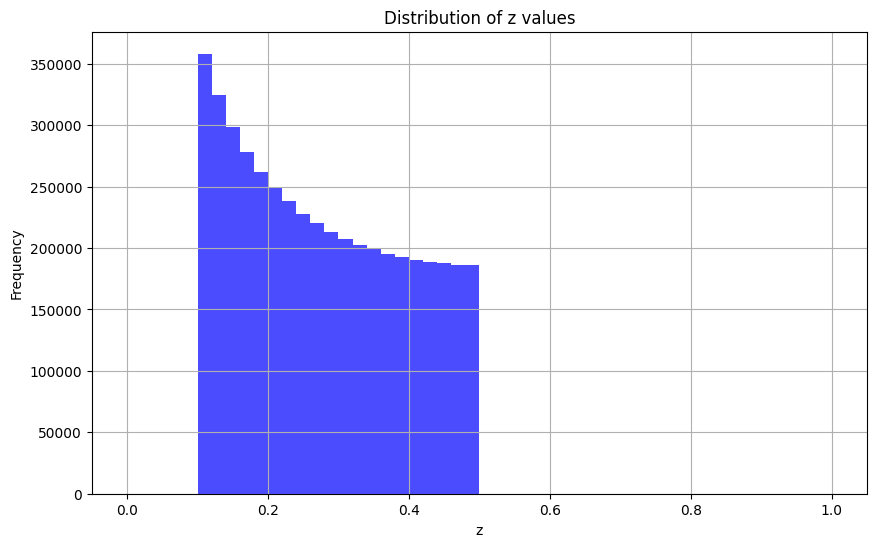

In [12]:
#plot z distribution
plt.figure(figsize=(10,6))
plt.hist(z_list_big, bins=50, range=(0,1), alpha=0.7, color='blue')
plt.title('Distribution of z values')
plt.xlabel('z')
plt.ylabel('Frequency')
plt.grid()
plt.show()

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =       762533
NDf                       =           99
Edm                       =  3.62128e-13
NCalls                    =           13
p0                        =      4489.17   +/-   6.70012     


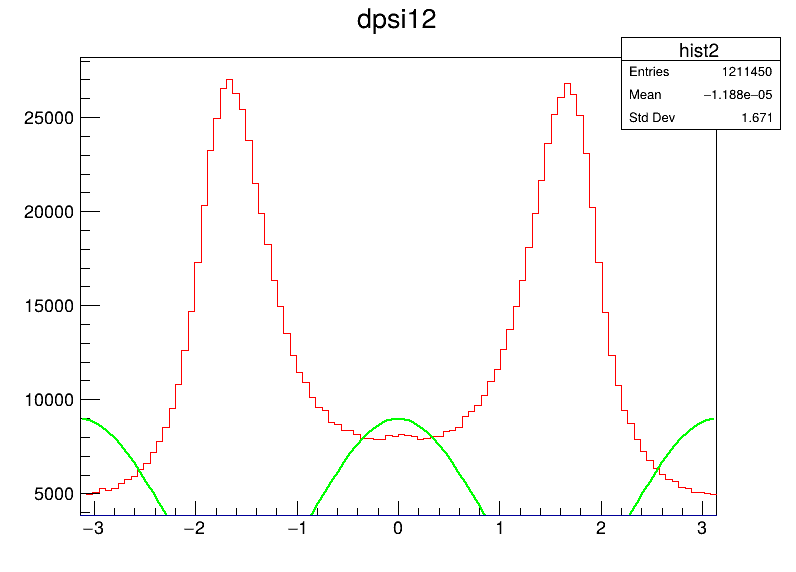

In [13]:
fit_func = ROOT.TF1("fit_func","[0]*(1+cos(2*x))", -np.pi, np.pi)
fit_func.SetLineColor(ROOT.kGreen)
fit_func.SetParameter(1, -1.0)  # Initial guess for the amplitude
#if (hist2.Integral() > 0) and (hist.Integral() > 0):
#    hist2.Scale(1.0 / hist2.Integral())
#    hist.Scale(1.0 / hist.Integral())

hist2.Fit(fit_func, "R")

hist2.Draw("hist")
fit_func.Draw("SAME")
hist.Draw("hist SAME")
hist2.SetLineColor(ROOT.kRed)
canvas.Draw()

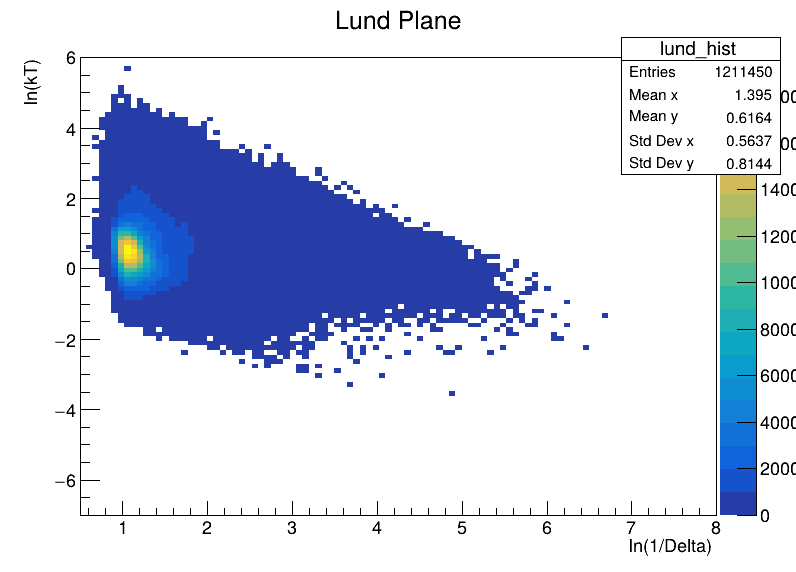

In [14]:
canvas.cd()
lund_hist.Draw("COLZ")
canvas.Draw()